# Imports

In [3]:
import numpy as np
import qutip as qt
import scqubits as scq
import matplotlib.pyplot as plt
%matplotlib inline
import scipy.optimize as opt

import copy
import tqdm

In [4]:
run_tests = True

# Defining Functions

## State Tracking

In [5]:
def state_tracking(state_history, other_sorts = [], reference_states = []):
    """
    This function tracks the states in a list and sorts them according to their overlap with the first state.

    Parameters:
    state_history (list): List of states to be sorted.
    other_sorts (list): List of other sorts to be considered.
    reference_states (list): List of reference states for sorting.

    Returns:
    list: Sorted list of states.
    """

    if len(reference_states) == 0:
        reference_states = state_history[0]

    history = []
    history_other_sorts = []
    previous_states = reference_states
    overlap_history = []
    for state in tqdm.tqdm(range(len(reference_states)), desc = 'Reference States'):
        psi_im1 = reference_states[state]
        history.append([])
        history_other_sorts.append([])
        overlap_history.append([])
        for step in range(len(state_history)):
            overlaps = []
            for j in range(len(state_history[step])):
                overlaps.append(abs(state_history[step][j].dag()*psi_im1))
    
            max_loc = np.argmax(overlaps)
            history[state].append(state_history[step][max_loc])
            to_append = []
            for sort in other_sorts:
                to_append.append(sort[step][max_loc])
            history_other_sorts[state].append(to_append)
            overlap_history[state].append(overlaps)
            psi_im1 = state_history[step][max_loc]

    return {"history": history, "other_sorts": history_other_sorts, "overlap_history": overlap_history}

## Floquet Drive Function Sweep

In [6]:
def Floquet_Sweep(drive_params, ham, drive_op, reference_states = [], sample_times = []):
    # Unless sample times are provided, we assume the sampling is at t=0
    if len(sample_times) == 0:
        sample_times = [0]*len(drive_params)
    
    floquet_bases = []
    floquet_modes = []
    floquet_energies = []
    completed_params = {}
    for i in tqdm.tqdm(range(len(drive_params)), desc = "Drive Parameters"):
        # Check if the drive parameters have already been computed
        if str(drive_params[i]) in completed_params.keys():
            floquet_modes.append(floquet_bases[completed_params[str(drive_params[i])]].mode(sample_times[i]))
            floquet_energies.append(floquet_energies[completed_params[str(drive_params[i])]])

        else:
            epsilon = drive_params[i]["epsilon"]
            freq = drive_params[i]["frequency"]
            drive_coef = lambda t: epsilon*np.sin(2*np.pi*freq*t)

            H_T = qt.QobjEvo([ham, [drive_op, drive_coef]])
            floquet_basis = qt.FloquetBasis(2*np.pi*H_T, 1/freq)
            floquet_bases.append(floquet_basis)
            floquet_modes.append(floquet_basis.mode(sample_times[i]))
            floquet_energies.append(floquet_basis.e_quasi)
            completed_params[str(drive_params[i])] = i
    
    sort_res = state_tracking(floquet_modes, other_sorts = [floquet_energies], reference_states = reference_states)

    return sort_res    


## Floquet Drive Time and Stark Shift Finder

In [7]:
def Find_Stark_Shift(ham, drive_op, base_freq, epsilon, stark_shifts, reference_states, show_plot = True):
    stark_shifts = np.array(stark_shifts)
    drive_freqs = base_freq + stark_shifts
    drive_params = []
    for drive_freq in drive_freqs:
        drive_params.append({"frequency": drive_freq, "epsilon": epsilon})
    
    floquet_sweep_res = Floquet_Sweep(drive_params, ham, drive_op, reference_states = reference_states)
    #return floquet_sweep_res

    q_vals1 = np.array([floquet_sweep_res["other_sorts"][0][i][0] for i in range(len(floquet_sweep_res["other_sorts"][0]))])/np.pi
    q_vals2 = np.array([floquet_sweep_res["other_sorts"][1][i][0] for i in range(len(floquet_sweep_res["other_sorts"][1]))])/np.pi
    #q_vals1[q_vals1<0] += 2*(drive_freqs[q_vals1<0])
    #q_vals2[q_vals2<0] += 2*(drive_freqs[q_vals2<0])

    absdifs = abs(q_vals1-q_vals2)

    to_fit = [min([absdifs[i], 2*(drive_freqs[i])-absdifs[i]]) for i in range(len(absdifs))]

    fit_func = lambda x, p0, p1, p2: p2*np.sqrt((x-p0)**2 + p1**2)
    p0 = stark_shifts[np.argmin(to_fit)]
    p1 = np.min(to_fit)
    p2 = abs((absdifs.max() - absdifs.min())/(stark_shifts[np.argmax(to_fit)] - stark_shifts[np.argmin(to_fit)]))
    p = [p0, p1, p2]

    fit_res = opt.curve_fit(fit_func, stark_shifts, to_fit, p0 = p)

    print(f"Fitted Stark Shift: {fit_res[0][0]} GHz")
    print(f"Approximate Drive Time: {1/(fit_res[0][1]*fit_res[0][2])} ns")
    
    if show_plot:
        fig, ax1 = plt.subplots(figsize=(8, 4), dpi = 200)

        # Plot q_vals1 and q_vals2 on the left y-axis
        ax1.set_xlabel("Stark Shift (GHz)")
        ax1.set_ylabel(r"Quasienergies/$\pi$ (GHz)")
        ax1.plot(stark_shifts, q_vals1, 'o:', label="State 1", color="forestgreen", lw = 0.5)
        ax1.plot(stark_shifts, q_vals2, 's:', label="State 2", color="dodgerblue", lw = 0.5)
        #ax1.tick_params(axis="y", labelcolor="tab:blue")

        # Create a twin y-axis for difs
        ax2 = ax1.twinx()
        ax2.set_ylabel("Difference (GHz)", color="firebrick")
        ax2.plot(stark_shifts, to_fit, 'd:', label="Difference", color="firebrick", lw = 0.5)

        x = np.linspace(stark_shifts.min(), stark_shifts.max(), 100)
        y = [fit_func(x[i], fit_res[0][0], fit_res[0][1], fit_res[0][2]) for i in range(len(x))]
        ax2.plot(x, y, color="firebrick", lw = 5, alpha = 0.2)
        ax2.tick_params(axis="y", labelcolor="tab:red")
        
        
        ax1.legend(loc="upper right")

        fig.tight_layout()
        plt.title("Stark Shift Fitting")
        plt.show()
    return [fit_res[0][0], 1/(fit_res[0][1]*fit_res[0][2])]




    


## Find Optimal Drive Time

In [8]:
def Get_Drive_Time(ham, drive_op, drive_freq, epsilon, base_envelope, t0, psi_i, psi_f):

    e_ops = [psi_f*psi_f.dag()]
    
    def to_minimize(x):
        drive_time = x[0]
        envelope = lambda t: base_envelope(t, drive_time)*np.cos(2*np.pi*drive_freq*t)
        H_T = qt.QobjEvo([ham, [drive_op, envelope]])
        
        sesolve_res = qt.sesolve(2*np.pi*H_T, psi_i, np.arange(0, drive_time, 1/drive_freq), e_ops = e_ops)
        #print(sesolve_res.expect)
        res = abs(1-sesolve_res.expect[0][-1])
        #print(res)
        return res


    min_res = opt.minimize(to_minimize, [t0])
    return min_res

    

In [15]:
def get_FLZ_flattop(H_op, drive_op, freq, epsilon, envelope_func, ramp_time, psi0, psi1, 
                    num_t_samples=10, epsilons_to_sample=[], n_theta_samples=100, dt=0):
    """
    Python conversion of the Julia get_FLZ_flattop function.
    
    Parameters:
    -----------
    H_op : qutip.Qobj
        The Hamiltonian operator
    drive_op : qutip.Qobj  
        The drive operator
    freq : float
        The drive frequency
    epsilon : float
        The drive amplitude
    envelope_func : function
        The envelope function that takes time as argument
    ramp_time : float
        The total ramp time
    psi0, psi1 : qutip.Qobj
        The two states to track
    num_t_samples : int, optional
        Number of time samples (default: 10)
    epsilons_to_sample : list, optional
        List of epsilon values to sample (if empty, will be generated)
    n_theta_samples : int, optional
        Number of theta samples for optimization (default: 100)
    dt : float, optional
        Time step (if 0, will be set to 1/freq)
        
    Returns:
    --------
    float
        The absolute value of θr/(2π*floq_frequency)
    """
    
    if dt == 0:
        dt = 1/freq
        
    times_to_sample = np.linspace(0, ramp_time, num_t_samples)
    
    if len(epsilons_to_sample) != len(times_to_sample):
        epsilons_to_sample = [[epsilon * envelope_func(t)] for t in times_to_sample]
    
    # Create drive parameters for Floquet sweep
    drive_params = []
    for eps_list in epsilons_to_sample:
        drive_params.append({"epsilon": eps_list[0], "frequency": freq})
    
    # Perform Floquet sweep using existing function
    states_to_track = [psi0, psi1]
    floq_sweep_res = Floquet_Sweep(drive_params, H_op, drive_op, 
                                   reference_states=states_to_track, 
                                   sample_times=times_to_sample)
    
    # Extract quasienergies for the final step
    final_step_idx = len(epsilons_to_sample) - 1
    quasi_energy_0 = floq_sweep_res["other_sorts"][0][final_step_idx][0]
    quasi_energy_1 = floq_sweep_res["other_sorts"][1][final_step_idx][0]
    
    floq_frequency = (quasi_energy_0 - quasi_energy_1) / (2 * np.pi)
    
    # Get final Floquet states
    psi0_floq = floq_sweep_res["history"][0][final_step_idx]
    psi1_floq = floq_sweep_res["history"][1][final_step_idx]
    
    # Create time-dependent Hamiltonian for evolution
    drive_coef = lambda t: epsilon * envelope_func(t) * np.sin(2 * np.pi * freq * t)
    H_drive = qt.QobjEvo([H_op, [drive_op, drive_coef]])
    
    # Solve time evolution
    times_evolution = np.arange(times_to_sample[0], times_to_sample[-1] + dt, dt)
    drive_res_0 = qt.sesolve(2 * np.pi * H_drive, psi0, times_evolution)
    psi0_final = drive_res_0.states[-1]
    
    # Optimization function to minimize
    def to_minimize(theta):
        theta_val = theta[0] if isinstance(theta, (list, np.ndarray)) else theta
        combination = psi0_floq + np.exp(1j * theta_val) * psi1_floq
        overlap = psi0_final.dag() * combination
        return 1 - abs(overlap)**2 / 2
    
    # Grid search for initial guess
    thetas = np.linspace(0, 2*np.pi, n_theta_samples)
    theta_values = [to_minimize(theta) for theta in thetas]
    theta_guess = thetas[np.argmin(theta_values)]
    
    # Optimize
    result = opt.minimize(to_minimize, [theta_guess], method='BFGS')
    theta_opt = result.x[0]
    
    # Calculate θr
    theta_r = np.mod(np.pi - 2 * theta_opt, 2 * np.pi)
    
    print(f"floq_frequency: {floq_frequency}")
    print(f"θ: {theta_opt}, θr: {theta_r}")
    
    return abs(theta_r / (2 * np.pi * floq_frequency))

In [ ]:
Bump_Ramp_Envelope(10, 10, ramp_time = 10)

0

In [ ]:
# Example usage of get_FLZ_flattop function
def demo_get_FLZ_flattop():
    """
    Demonstrates how to use the get_FLZ_flattop function with the existing transmon-cavity system.
    """
    # Use the existing system parameters
    ham = hilbertspace.hamiltonian()
    drive_op = scq.identity_wrap(transmon.n_operator(), transmon, [transmon, oscillator])
    
    # Define envelope function (using existing Bump_Ramp_Envelope)
    def envelope_func(t):
        return Bump_Ramp_Envelope(t, 2*ramp_time, ramp_time=ramp_time, k=2)
    
    # Call the function
    result = get_FLZ_flattop(
        H_op=ham,
        drive_op=drive_op, 
        freq=drive_freq,
        epsilon=epsilon,
        envelope_func=envelope_func,
        ramp_time=10.0,  # example ramp time
        psi0=psi_e0,
        psi1=psi_g2,
        num_t_samples=20,
        n_theta_samples=50
    )
    
    print(f"FLZ result: {result}")
    return result

# Uncomment the line below to run the demo:
demo_result = demo_get_FLZ_flattop()

 /Users/gavinrockwood/.pyenv/versions/FloquetDemo/lib/python3.11/site-packages/scqubits/utils/spectrum_utils.py: 199RuntimeWarning: overflow encountered in matmul
 /Users/gavinrockwood/.pyenv/versions/FloquetDemo/lib/python3.11/site-packages/scqubits/utils/spectrum_utils.py: 199RuntimeWarning: invalid value encountered in matmul
 /Users/gavinrockwood/.pyenv/versions/FloquetDemo/lib/python3.11/site-packages/scqubits/utils/spectrum_utils.py: 199

3.5083554363678924


Reference States: 100%|██████████| 2/2 [00:00<00:00, 441.88it/s]

floq_frequency: 0.00244266632752528
θ: 3.156319342352925, θr: 3.1121392760635294
FLZ result: 202.7752803542985


## Other Stuff

### Drive Envelopes

#### Bump Ramp

In [9]:
def Bump_Envelope(t, drive_time, k=2, center=None):
    if center is None:
        center = drive_time / 2
    x = (t - center) / (drive_time / 2)
    if x <= -1 or x >= 1:
        return 0
    elif x == 0:
        return 1
    else:
        return np.exp(k * x**2 / (x**2 - 1))

def Bump_Ramp_Envelope(t, drive_time, ramp_time=1, k=2):
    if t < ramp_time:
        return Bump_Envelope(t, 2 * ramp_time, k=k)
    elif ramp_time <= t <= (drive_time - ramp_time):
        return 1
    elif t > (drive_time - ramp_time):
        return Bump_Envelope(t, 2 * ramp_time, k=k, center=drive_time - ramp_time)

# Transmon-Cavity Sideband Example

#### Making Model

In [10]:
EJ = 29
EC = 0.1
g = 0.05
osc_freq = 4.109

transmon = scq.Transmon(
    EJ=EJ,
    EC=EC,
    ncut=60,
    ng=0.0,
    truncated_dim = 6)

oscillator = scq.Oscillator(osc_freq, truncated_dim=5)

hilbertspace = scq.HilbertSpace([transmon, oscillator])
hilbertspace.add_interaction(g = g,
        op1 = transmon.n_operator,
        op2 = oscillator.creation_operator, add_hc = True)

hilbertspace.generate_lookup()        

 /Users/gavinrockwood/.pyenv/versions/FloquetDemo/lib/python3.11/site-packages/scqubits/utils/spectrum_utils.py: 199RuntimeWarning: overflow encountered in matmul
 /Users/gavinrockwood/.pyenv/versions/FloquetDemo/lib/python3.11/site-packages/scqubits/utils/spectrum_utils.py: 199RuntimeWarning: invalid value encountered in matmul
 /Users/gavinrockwood/.pyenv/versions/FloquetDemo/lib/python3.11/site-packages/scqubits/utils/spectrum_utils.py: 199

#### Finding e0g2 sideband

##### Finding the Stark Shift

Reference States: 100%|██████████| 2/2 [00:00<00:00, 829.90it/s]


Fitted Stark Shift: 0.04148543636789238 GHz
Approximate Drive Time: 207.17772618360553 ns


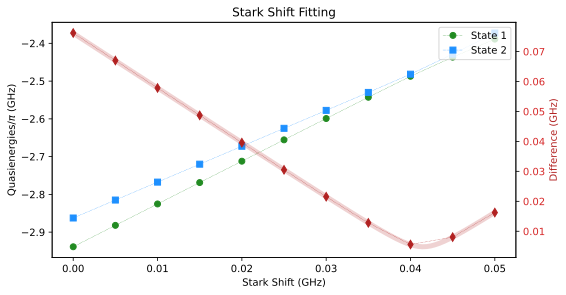

In [11]:
epsilon = 0.7
base_freq = 3.46687
stark_shifts = np.linspace(0, 0.05, 11)

psi_e0 = hilbertspace.eigensys(hilbertspace.dimension)[1][hilbertspace.dressed_index((1,0))]
psi_g2 = hilbertspace.eigensys(hilbertspace.dimension)[1][hilbertspace.dressed_index((0,2))]


drive_op = scq.identity_wrap(transmon.n_operator(), transmon, [transmon, oscillator])

stark_shift_fit_res = Find_Stark_Shift(hilbertspace.hamiltonian(), drive_op, base_freq, epsilon, stark_shifts, reference_states = [psi_e0, psi_g2])

In [12]:
qt.version.version

'5.1.1'

##### Getting Drive Time

In [13]:
ham = hilbertspace.hamiltonian()
drive_op = scq.identity_wrap(transmon.n_operator(), transmon, [transmon, oscillator])

drive_freq = base_freq + stark_shift_fit_res[0]

ramp_time = 10
base_envelope = lambda t, drive_time: epsilon*Bump_Ramp_Envelope(t, drive_time, ramp_time = ramp_time) 

t0 = stark_shift_fit_res[1]#+ramp_time

psi_i = psi_e0
psi_f = psi_g2

drive_time_fit = Get_Drive_Time(ham, drive_op, drive_freq, epsilon, base_envelope, t0, psi_i, psi_f)

 /Users/gavinrockwood/.pyenv/versions/FloquetDemo/lib/python3.11/site-packages/scqubits/utils/spectrum_utils.py: 199RuntimeWarning: overflow encountered in matmul
 /Users/gavinrockwood/.pyenv/versions/FloquetDemo/lib/python3.11/site-packages/scqubits/utils/spectrum_utils.py: 199RuntimeWarning: invalid value encountered in matmul
 /Users/gavinrockwood/.pyenv/versions/FloquetDemo/lib/python3.11/site-packages/scqubits/utils/spectrum_utils.py: 199

In [14]:
print(t0)
print(drive_time_fit)

207.17772618360553
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.00011749026497154258
        x: [ 2.121e+02]
      nit: 4
      jac: [-1.095e-06]
 hess_inv: [[ 8.274e+03]]
     nfev: 20
     njev: 10


#### Getting Sideband Time Evolution Data

In [27]:
psi_e0 = hilbertspace.eigensys(hilbertspace.dimension)[1][hilbertspace.dressed_index((1,0))]
psi_g0 = hilbertspace.eigensys(hilbertspace.dimension)[1][hilbertspace.dressed_index((0,0))]
psi_f0 = hilbertspace.eigensys(hilbertspace.dimension)[1][hilbertspace.dressed_index((2,0))]
psi_g2 = hilbertspace.eigensys(hilbertspace.dimension)[1][hilbertspace.dressed_index((0,2))]
psi_g1 = hilbertspace.eigensys(hilbertspace.dimension)[1][hilbertspace.dressed_index((0,1))]
psi_e2 = hilbertspace.eigensys(hilbertspace.dimension)[1][hilbertspace.dressed_index((1,2))]

e_e0 = hilbertspace.eigensys(hilbertspace.dimension)[0][hilbertspace.dressed_index((1,0))]
e_g2 = hilbertspace.eigensys(hilbertspace.dimension)[0][hilbertspace.dressed_index((0,2))]

print("Base Frequency:",e_g2 - e_e0)

Base Frequency: 3.46687123419213


In [28]:
stark_shift = stark_shift_fit_res[0]
drive_freq = base_freq + stark_shift

drive_time = drive_time_fit.x[0]#214.916
ramp_time = 10
drive_time = 2*ramp_time + 202.7752803542985
envelope = lambda t: epsilon * Bump_Ramp_Envelope(t, drive_time, ramp_time=ramp_time, k=2)

drive_coef = lambda t: envelope(t) * np.sin(2*np.pi*drive_freq*t)

drive_op = scq.identity_wrap(transmon.n_operator(), transmon, [transmon, oscillator])

H_T = qt.QobjEvo([hilbertspace.hamiltonian(), [drive_op, drive_coef]])

In [29]:
e_ops = [psi_e0*psi_e0.dag(), psi_g2*psi_g2.dag(), psi_f0*psi_f0.dag(), psi_g0*psi_g0.dag()]
times = np.arange(0, drive_time, 1/drive_freq)
#times = np.linspace(0, drive_time, int(drive_time*drive_freq))
run_res = qt.sesolve(2*np.pi*H_T, psi_e0, times, e_ops = e_ops, options = {"store_states":True, "nsteps":10000})

In [30]:
run_res.expect[0][-1]

np.float64(0.0066666687402796646)

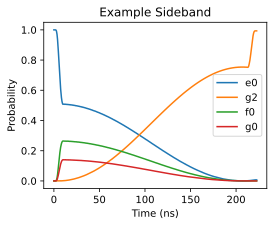

In [31]:
plt.figure(figsize=(4, 3), dpi = 150)
plt.plot(run_res.times, run_res.expect[0], label = 'e0')
plt.plot(run_res.times, run_res.expect[1], label = 'g2')
plt.plot(run_res.times, run_res.expect[2], label = 'f0')
plt.plot(run_res.times, run_res.expect[3], label = 'g0')


plt.xlabel('Time (ns)')
plt.ylabel('Probability')
plt.title('Example Sideband')
plt.legend()

#### Getting Floquet States

In [32]:
drive_params = []
for t in run_res.times:
    drive_params.append({"epsilon": envelope(t), "frequency": drive_freq})

floq_sweep_res = Floquet_Sweep(drive_params, hilbertspace.hamiltonian(), drive_op, sample_times = run_res.times, reference_states = [psi_e0, psi_g2])

 /Users/gavinrockwood/.pyenv/versions/FloquetDemo/lib/python3.11/site-packages/scqubits/utils/spectrum_utils.py: 199RuntimeWarning: overflow encountered in matmul
 /Users/gavinrockwood/.pyenv/versions/FloquetDemo/lib/python3.11/site-packages/scqubits/utils/spectrum_utils.py: 199RuntimeWarning: invalid value encountered in matmul
Reference States: 100%|██████████| 2/2 [00:00<00:00, 24.79it/s]


In [33]:
proj_to_e0 = [run_res.states[i].dag() * floq_sweep_res["history"][0][i] for i in range(len(run_res.states))]
proj_to_g2 = [run_res.states[i].dag() * floq_sweep_res["history"][1][i] for i in range(len(run_res.states))]

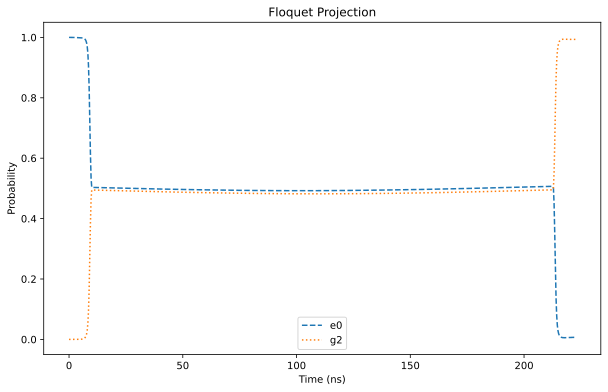

In [34]:
plt.figure(figsize=(10, 6), dpi = 150)
plt.plot(run_res.times, [abs(x)**2 for x in proj_to_e0], label = 'e0', linestyle = '--')
plt.plot(run_res.times, [abs(x)**2 for x in proj_to_g2], label = 'g2', linestyle = ":")

plt.xlabel('Time (ns)')
plt.ylabel('Probability')
plt.title('Floquet Projection')
plt.legend()